# Qualifying-language discovery — primary models

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
def find_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        q=p/"tasks/political-compass/qualitative-analysis"
        if (q/"config.py").exists(): return q
        if p.name=="qualitative-analysis" and (p/"config.py").exists(): return p
    raise FileNotFoundError
ROOT=find_root(); TABLES=ROOT/"artifacts/tables"; FIGURES=ROOT/"artifacts/figures"
CHAT_ORDER=["gemma-3-1b-it","gemma-3-4b-it","gemma-3-12b-it","gemma-3-27b-it",
"Qwen3-4B_no_think","Qwen3-8B_no_think","Qwen3-14B_no_think","Qwen3-32B_no_think",
"Qwen3-4B_think","Qwen3-8B_think","Qwen3-14B_think","Qwen3-32B_think"]
LABEL=dict(zip(CHAT_ORDER,["Gemma 1B","Gemma 4B","Gemma 12B","Gemma 27B",
"Qwen 4B","Qwen 8B","Qwen 14B","Qwen 32B","Qwen 4B Think","Qwen 8B Think",
"Qwen 14B Think","Qwen 32B Think"]))
def ordered(d,col="model_variant"):
    d=d[d[col].isin(CHAT_ORDER)].copy(); d["model_label"]=d[col].map(LABEL)
    d["model_label"]=pd.Categorical(d.model_label,[LABEL[x] for x in CHAT_ORDER],ordered=True)
    return d.sort_values("model_label")
sns.set_theme(style="whitegrid")


Scope: four Gemma sizes and four Qwen sizes, with Qwen no-think and think modes. The outcome is qualifying-cue incidence. Pragmatic hedging, uncertainty, caution, and safety motivation require contextual human validation.

,model_label,regime,informative_questions,substantive_pockets,right_more_pockets,left_more_pockets,mean_risk_difference
42,Gemma 1B,authoritarian,62,10,10,0,0.021720
43,Gemma 1B,libertarian,60,2,0,2,0.002903
46,Gemma 4B,authoritarian,62,37,11,26,-0.020269
47,Gemma 4B,libertarian,62,32,2,30,-0.049892
40,Gemma 12B,authoritarian,62,46,22,24,-0.003441
41,Gemma 12B,libertarian,62,41,18,23,-0.016344
45,Gemma 27B,libertarian,62,33,14,19,-0.004355
44,Gemma 27B,authoritarian,62,36,21,15,0.001290
32,Qwen 4B,authoritarian,62,34,20,14,0.012796
33,Qwen 4B,libertarian,62,35,15,20,-0.010376


,feature,regime,question_id,topic,direction,support_models,support_families,support_parent_families,max_abs_risk_difference,median_risk_difference,all_ci_exclude_zero
0,hedging,authoritarian,20,competition_monopoly,right_more,12,2,2,0.243333,0.158333,True
1,hedging,libertarian,34,welfare_work,left_more,11,2,2,0.310000,-0.170000,True
2,hedging,authoritarian,14,finance_inequality,right_more,11,2,2,0.290000,0.186667,True
3,hedging,authoritarian,16,corporate_responsibility,right_more,11,2,2,0.273333,0.210000,True
4,hedging,authoritarian,21,abortion,left_more,11,2,2,0.273333,-0.150000,True
5,hedging,authoritarian,54,fate_responsibility,right_more,11,2,2,0.233333,0.116667,True
6,hedging,authoritarian,18,healthcare_inequality,right_more,11,2,2,0.223333,0.126667,False
7,hedging,authoritarian,42,punishment_justice,left_more,11,2,2,0.220000,-0.120000,True
8,hedging,authoritarian,43,hierarchy_authority,left_more,11,2,2,0.216667,-0.113333,True
9,hedging,authoritarian,12,commodification,right_more,11,2,2,0.213333,0.133333,True


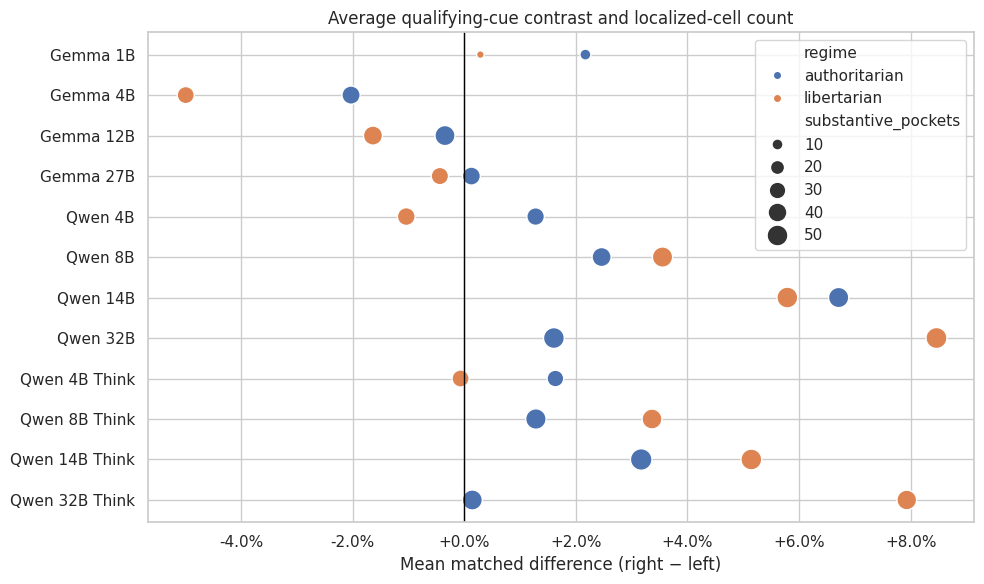

In [2]:
H=TABLES/"expressive_heterogeneity_primary"; c=pd.read_csv(H/"question_cells.csv"); m=ordered(pd.read_csv(H/"model_summary.csv")); r=pd.read_csv(H/"question_recurrence.csv")
display(m[m.feature=="hedging"][["model_label","regime","informative_questions","substantive_pockets","right_more_pockets","left_more_pockets","mean_risk_difference"]])
display(r[r.feature=="hedging"].head(40))
hm=m[m.feature=="hedging"].copy()
fig,ax=plt.subplots(figsize=(10,6)); sns.scatterplot(data=hm,x="mean_risk_difference",y="model_label",hue="regime",size="substantive_pockets",sizes=(30,240),ax=ax)
ax.axvline(0,color="black",lw=1); ax.xaxis.set_major_formatter(lambda x,_:f"{x:+.1%}")
ax.set(title="Average qualifying-cue contrast and localized-cell count",xlabel="Mean matched difference (right − left)",ylabel="")
plt.tight_layout(); plt.savefig(FIGURES/"primary_qualifying_contrast_pockets.png",bbox_inches="tight",dpi=180); plt.show()

,model_label,left_rate,right_rate,risk_difference,informative,substantive
2434,Gemma 1B,0.076667,0.070000,-0.006667,True,False
1600,Gemma 4B,0.386667,0.186667,-0.200000,True,True
1608,Gemma 12B,0.540000,0.233333,-0.306667,True,True
1606,Gemma 27B,0.473333,0.253333,-0.220000,True,True
1592,Qwen 4B,0.333333,0.163333,-0.170000,True,True
1566,Qwen 8B,0.310000,0.220000,-0.090000,True,True
1596,Qwen 14B,0.423333,0.233333,-0.190000,True,True
1609,Qwen 32B,0.440000,0.130000,-0.310000,True,True
1580,Qwen 4B Think,0.266667,0.130000,-0.136667,True,True
1591,Qwen 8B Think,0.343333,0.176667,-0.166667,True,True


Left-more by ≥5 points: 11 of 12 primary variants


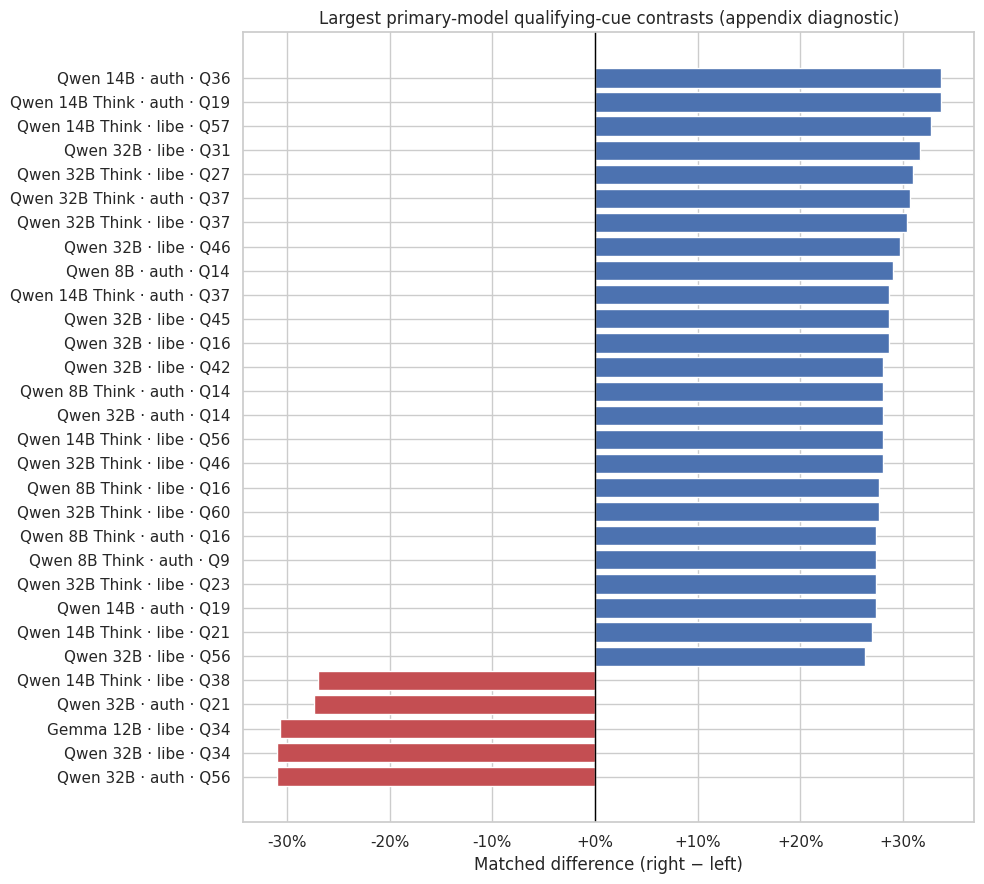

In [3]:
q=ordered(c[(c.feature=="hedging")&(c.regime=="libertarian")&(c.question_id==34)])
display(q[["model_label","left_rate","right_rate","risk_difference","informative","substantive"]])
print("Left-more by ≥5 points:",int((q.risk_difference<=-.05).sum()),"of",len(q),"primary variants")
top=c[(c.feature=="hedging")&c.substantive].copy()
top=top.loc[top.risk_difference.abs().nlargest(30).index].sort_values("risk_difference")
top["model_label"]=top.model_variant.map(LABEL); top["label"]=top.model_label+" · "+top.regime.str[:4]+" · Q"+top.question_id.astype(str)
fig,ax=plt.subplots(figsize=(10,9)); ax.barh(top.label,top.risk_difference,color=np.where(top.risk_difference>0,"#4c72b0","#c44e52"))
ax.axvline(0,color="black",lw=1); ax.xaxis.set_major_formatter(lambda x,_:f"{x:+.0%}")
ax.set(title="Largest primary-model qualifying-cue contrasts (appendix diagnostic)",xlabel="Matched difference (right − left)",ylabel="")
plt.tight_layout(); plt.savefig(FIGURES/"primary_qualifying_largest_cells.png",bbox_inches="tight",dpi=180); plt.show()

,feature,size_b,regime,questions,both_informative,risk_difference_correlation,both_substantive,same_direction_substantive,opposite_direction_substantive,think_only_substantive,no_think_only_substantive
8,hedging,4.0,authoritarian,62,62,0.742130,22,22,0,8,12
9,hedging,4.0,libertarian,62,62,0.717849,23,23,0,9,12
10,hedging,8.0,authoritarian,62,62,0.825819,36,35,1,12,5
11,hedging,8.0,libertarian,62,62,0.839632,37,37,0,8,10
12,hedging,14.0,authoritarian,62,62,0.835172,42,40,2,12,5
13,hedging,14.0,libertarian,62,62,0.856932,42,41,1,8,8
14,hedging,32.0,authoritarian,62,62,0.841765,41,40,1,5,9
15,hedging,32.0,libertarian,62,62,0.850604,39,38,1,5,12


,feature,cells,informative,pockets,coverage
0,actual_refusal,1488,0,0,0.000000
1,hedging,1488,1486,941,0.998656
2,moral_distance,1488,188,122,0.126344
3,persona_meta,1488,1455,560,0.977823
4,self_correction,1488,53,19,0.035618


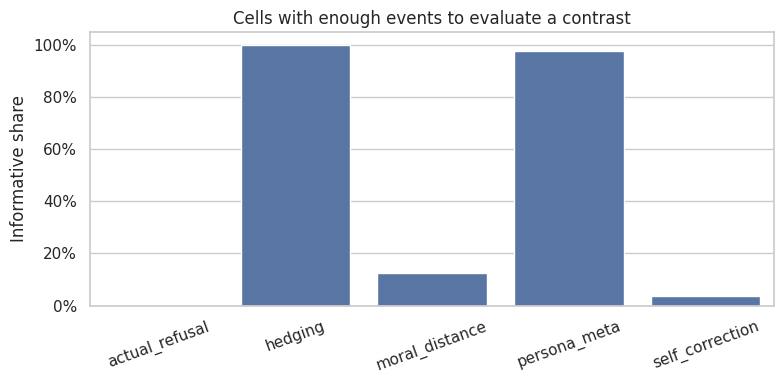

In [4]:
s=pd.read_csv(H/"qwen_protocol_stability.csv"); display(s[s.feature=="hedging"].sort_values(["size_b","regime"]))
v=c.groupby("feature").agg(cells=("question_id","size"),informative=("informative","sum"),pockets=("substantive","sum")).reset_index(); v["coverage"]=v.informative/v.cells; display(v)
fig,ax=plt.subplots(figsize=(8,4)); sns.barplot(data=v,x="feature",y="coverage",color="#4c72b0",ax=ax)
ax.set(title="Cells with enough events to evaluate a contrast",xlabel="",ylabel="Informative share"); ax.tick_params(axis="x",rotation=20)
ax.yaxis.set_major_formatter(lambda x,_:f"{x:.0%}"); plt.tight_layout(); plt.savefig(FIGURES/"primary_expressive_measure_coverage.png",bbox_inches="tight",dpi=180); plt.show()

In [5]:
question_rates=pd.read_csv(TABLES/"primary_question_qualifying_cue_rates.csv")
display(question_rates.sort_values("qualifying_cue_incidence",ascending=False).head(20))
print("Each proposition denominator:",int(question_rates["count"].iloc[0]),"answers; maximum incidence:",f"{question_rates.qualifying_cue_incidence.max():.1%}")
for qid,regime in [(20,"authoritarian"),(34,"libertarian"),(42,"authoritarian")]:
    z=ordered(c[(c.feature=="hedging")&(c.regime==regime)&(c.question_id==qid)])
    print(f"Q{qid} ({regime}):",int(z.substantive.sum()),"of",len(z),"primary variants cross the five-point screen")
    display(z[["model_label","left_rate","right_rate","risk_difference","informative","substantive"]])

,question_id,sum,count,qualifying_cue_incidence
5,5,9995,21600,0.462731
4,4,9666,21600,0.447500
40,40,9005,21600,0.416898
38,38,8350,21600,0.386574
31,31,8226,21600,0.380833
15,15,8105,21600,0.375231
27,27,8040,21600,0.372222
48,48,7890,21600,0.365278
46,46,7739,21600,0.358287
33,33,7667,21600,0.354954


Each proposition denominator: 21600 answers; maximum incidence: 46.3%
Q20 (authoritarian): 12 of 12 primary variants cross the five-point screen


,model_label,left_rate,right_rate,risk_difference,informative,substantive
1498,Gemma 1B,0.063333,0.123333,0.060000,True,True
1499,Gemma 4B,0.136667,0.186667,0.050000,True,True
1495,Gemma 12B,0.120000,0.253333,0.133333,True,True
1496,Gemma 27B,0.143333,0.276667,0.133333,True,True
1494,Qwen 4B,0.053333,0.203333,0.150000,True,True
1491,Qwen 8B,0.110000,0.323333,0.213333,True,True
1488,Qwen 14B,0.120000,0.363333,0.243333,True,True
1490,Qwen 32B,0.160000,0.373333,0.213333,True,True
1497,Qwen 4B Think,0.096667,0.180000,0.083333,True,True
1493,Qwen 8B Think,0.146667,0.313333,0.166667,True,True


Q34 (libertarian): 11 of 12 primary variants cross the five-point screen


,model_label,left_rate,right_rate,risk_difference,informative,substantive
2434,Gemma 1B,0.076667,0.070000,-0.006667,True,False
1600,Gemma 4B,0.386667,0.186667,-0.200000,True,True
1608,Gemma 12B,0.540000,0.233333,-0.306667,True,True
1606,Gemma 27B,0.473333,0.253333,-0.220000,True,True
1592,Qwen 4B,0.333333,0.163333,-0.170000,True,True
1566,Qwen 8B,0.310000,0.220000,-0.090000,True,True
1596,Qwen 14B,0.423333,0.233333,-0.190000,True,True
1609,Qwen 32B,0.440000,0.130000,-0.310000,True,True
1580,Qwen 4B Think,0.266667,0.130000,-0.136667,True,True
1591,Qwen 8B Think,0.343333,0.176667,-0.166667,True,True


Q42 (authoritarian): 11 of 12 primary variants cross the five-point screen


,model_label,left_rate,right_rate,risk_difference,informative,substantive
2896,Gemma 1B,0.140000,0.160000,0.020000,True,False
1574,Gemma 4B,0.283333,0.170000,-0.113333,True,True
1598,Gemma 12B,0.433333,0.236667,-0.196667,True,True
1599,Gemma 27B,0.423333,0.226667,-0.196667,True,True
1561,Qwen 4B,0.243333,0.166667,-0.076667,True,True
1568,Qwen 8B,0.300000,0.200000,-0.100000,True,True
1556,Qwen 14B,0.233333,0.176667,-0.056667,True,True
1605,Qwen 32B,0.390000,0.170000,-0.220000,True,True
1560,Qwen 4B Think,0.213333,0.143333,-0.070000,True,True
1575,Qwen 8B Think,0.273333,0.153333,-0.120000,True,True
